In [8]:
# Behavioral Data Analysis Notebook
# ===============================
# This notebook analyzes behavioral data from the center-out task
# - Visualizes specific trials with velocity and trajectory data
# - Summarizes trial outcomes and statistics
# - Provides detailed analysis of behavioral patterns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure paths
NS6_FILE_PATH = r"D:\Data\ScienceCorp\neural.ns6"
CSV_FILE_PATH = r"D:\Data\ScienceCorp\actions.csv"

# Initialize data loader
from utils.data_loader import DataLoader

print("🎯 Behavioral Data Analysis")
print("=" * 50)
print(f"Neural file: {NS6_FILE_PATH}")
print(f"Behavioral file: {CSV_FILE_PATH}")
print("=" * 50)


🎯 Behavioral Data Analysis
Neural file: D:\Data\ScienceCorp\neural.ns6
Behavioral file: D:\Data\ScienceCorp\actions.csv


In [9]:
# Load Behavioral Data
print("📊 Loading behavioral data...")

# Create data loader instance
loader = DataLoader(ns6_file_path=NS6_FILE_PATH, csv_file_path=CSV_FILE_PATH)

# Load behavioral data
behavioral_data = loader.load_behavioral_data()

if behavioral_data is not None:
    print(f"\n✅ Behavioral data loaded successfully!")
    print(f"Shape: {behavioral_data.shape}")
    print(f"Columns: {list(behavioral_data.columns)}")
    
    # Display first few rows
    print("\n📋 Data Preview:")
    print(behavioral_data.head())
    
    # Show data types
    print("\n🔍 Data Types:")
    print(behavioral_data.dtypes)
    
else:
    print("❌ Failed to load behavioral data")
    print("Check file path and format")


📊 Loading behavioral data...
Found 141 trial start markers
Trial segmentation complete: 141 trials identified
Behavioral data loaded successfully!
Shape: (45971, 10)
Columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial_start', 'trial_win', 'trial_lose', 'num_targets', 'target_index', 'trial', 'trial_outcome']
Trials segmented: 141 trials identified
Trial outcomes: {'win': 127, 'lose': 13, 'incomplete': 1}

✅ Behavioral data loaded successfully!
Shape: (45971, 10)
Columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial_start', 'trial_win', 'trial_lose', 'num_targets', 'target_index', 'trial', 'trial_outcome']

📋 Data Preview:
                      timestamp  velocity_x  velocity_y  trial_start  \
0 1970-01-01 00:00:01.742937748         0.0         0.0         True   
1 1970-01-01 00:00:01.742937748         0.0         0.0        False   
2 1970-01-01 00:00:01.742937748         0.0         0.0        False   
3 1970-01-01 00:00:01.742937748         0.0         0.0        False   


In [10]:
# Trial Summary Analysis
print("📈 Trial Summary Analysis")
print("=" * 40)

if behavioral_data is not None:
    # Total number of trials
    if 'trial' in behavioral_data.columns:
        total_trials = behavioral_data['trial'].nunique()
        print(f"📊 Total number of trials: {total_trials}")
        
        # Trial outcomes summary
        if 'trial_outcome' in behavioral_data.columns:
            outcome_counts = behavioral_data.groupby('trial')['trial_outcome'].first().value_counts()
            print(f"\n🎯 Trial Outcomes:")
            for outcome, count in outcome_counts.items():
                percentage = (count / total_trials) * 100
                print(f"  - {outcome.capitalize()}: {count} trials ({percentage:.1f}%)")
            
            # Failed/unfinished trials
            failed_trials = outcome_counts.get('lose', 0)
            incomplete_trials = outcome_counts.get('incomplete', 0)
            unsuccessful_trials = failed_trials + incomplete_trials
            
            print(f"\n❌ Failed or unfinished trials: {unsuccessful_trials}")
            print(f"   - Failed: {failed_trials}")
            print(f"   - Incomplete: {incomplete_trials}")
            
            # Success rate
            successful_trials = outcome_counts.get('win', 0)
            success_rate = (successful_trials / total_trials) * 100
            print(f"   - Success rate: {success_rate:.1f}%")
            
        # Trial duration analysis
        print(f"\n⏱️ Trial Duration Analysis:")
        trial_durations = []
        for trial_num in behavioral_data['trial'].unique():
            trial_data = behavioral_data[behavioral_data['trial'] == trial_num]
            duration = len(trial_data)  # Duration in samples
            trial_durations.append(duration)
        
        print(f"   - Mean duration: {np.mean(trial_durations):.1f} samples")
        print(f"   - Median duration: {np.median(trial_durations):.1f} samples")
        print(f"   - Min duration: {np.min(trial_durations)} samples")
        print(f"   - Max duration: {np.max(trial_durations)} samples")
        
        # Target distribution
        if 'target_index' in behavioral_data.columns:
            print(f"\n🎯 Target Distribution:")
            target_counts = behavioral_data.groupby('trial')['target_index'].first().value_counts().sort_index()
            for target, count in target_counts.items():
                percentage = (count / total_trials) * 100
                print(f"   - Target {target}: {count} trials ({percentage:.1f}%)")
            
    else:
        print("❌ No trial information found in data")
        
else:
    print("❌ No behavioral data available")


📈 Trial Summary Analysis
📊 Total number of trials: 141

🎯 Trial Outcomes:
  - Win: 127 trials (90.1%)
  - Lose: 13 trials (9.2%)
  - Incomplete: 1 trials (0.7%)

❌ Failed or unfinished trials: 14
   - Failed: 13
   - Incomplete: 1
   - Success rate: 90.1%

⏱️ Trial Duration Analysis:
   - Mean duration: 326.0 samples
   - Median duration: 96.0 samples
   - Min duration: 55 samples
   - Max duration: 8826 samples

🎯 Target Distribution:
   - Target 0: 28 trials (19.9%)
   - Target 1: 14 trials (9.9%)
   - Target 2: 16 trials (11.3%)
   - Target 3: 13 trials (9.2%)
   - Target 4: 19 trials (13.5%)
   - Target 5: 15 trials (10.6%)
   - Target 6: 19 trials (13.5%)
   - Target 7: 17 trials (12.1%)


In [11]:
# Visualization Function for Single Trial
def visualize_trial(trial_num, data=None, figsize=(15, 10)):
    """
    Visualize a single trial with velocity profiles and trajectory.
    
    Parameters:
    -----------
    trial_num : int
        Trial number to visualize
    data : pd.DataFrame, optional
        Behavioral data. If None, uses global behavioral_data
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    if data is None:
        data = behavioral_data
    
    if data is None:
        print("❌ No behavioral data available")
        return None
    
    # Check if trial exists
    if 'trial' not in data.columns:
        print("❌ No trial information in data")
        return None
        
    available_trials = sorted(data['trial'].unique())
    if trial_num not in available_trials:
        print(f"❌ Trial {trial_num} not found. Available trials: {available_trials[:10]}...")
        return None
    
    # Extract trial data
    trial_data = data[data['trial'] == trial_num].copy()
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'Trial {trial_num} Analysis', fontsize=16)
    
    # Time axis (use sample indices for simplicity)
    time_axis = np.arange(len(trial_data))
    
    # Plot 1: Velocity X and Y
    ax1 = axes[0, 0]
    if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
        ax1.plot(time_axis, trial_data['velocity_x'], 'b-', label='Velocity X', linewidth=2)
        ax1.plot(time_axis, trial_data['velocity_y'], 'r-', label='Velocity Y', linewidth=2)
        ax1.set_xlabel('Time (samples)')
        ax1.set_ylabel('Velocity')
        ax1.set_title('Velocity Profiles')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    else:
        ax1.text(0.5, 0.5, 'Velocity data\nnot available', 
                ha='center', va='center', transform=ax1.transAxes)
    
    # Plot 2: Speed (magnitude)
    ax2 = axes[0, 1]
    if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
        speed = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
        ax2.plot(time_axis, speed, 'g-', linewidth=2)
        ax2.set_xlabel('Time (samples)')
        ax2.set_ylabel('Speed')
        ax2.set_title('Speed Profile')
        ax2.grid(True, alpha=0.3)
        
        # Add speed statistics
        max_speed = np.max(speed)
        mean_speed = np.mean(speed)
        ax2.axhline(max_speed, color='red', linestyle='--', alpha=0.7, label=f'Max: {max_speed:.2f}')
        ax2.axhline(mean_speed, color='orange', linestyle='--', alpha=0.7, label=f'Mean: {mean_speed:.2f}')
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'Speed data\nnot available', 
                ha='center', va='center', transform=ax2.transAxes)
    
    # Plot 3: Trajectory from integrated velocity
    ax3 = axes[1, 0]
    if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
        # Simple integration (assuming constant time step)
        dt = 1.0  # Time step in arbitrary units
        pos_x = np.cumsum(trial_data['velocity_x'] * dt)
        pos_y = np.cumsum(trial_data['velocity_y'] * dt)
        
        # Center trajectory at origin
        pos_x = pos_x - pos_x[0]
        pos_y = pos_y - pos_y[0]
        
        # Plot trajectory
        ax3.plot(pos_x, pos_y, 'purple', linewidth=3, alpha=0.8)
        ax3.plot(pos_x[0], pos_y[0], 'go', markersize=8, label='Start')
        ax3.plot(pos_x[-1], pos_y[-1], 'ro', markersize=8, label='End')
        
        # Add center point
        ax3.plot(0, 0, 'ko', markersize=8, label='Center')
        
        # Add target if available
        if 'target_index' in trial_data.columns:
            target_idx = trial_data['target_index'].iloc[0]
            # Assume 8 targets in circle
            target_angle = target_idx * (2 * np.pi / 8)
            # Estimate target distance
            trajectory_distance = np.sqrt(pos_x[-1]**2 + pos_y[-1]**2)
            target_distance = max(1.0, trajectory_distance * 1.2)
            
            target_x = target_distance * np.cos(target_angle)
            target_y = target_distance * np.sin(target_angle)
            ax3.plot(target_x, target_y, 'rs', markersize=10, label=f'Target {target_idx}')
        
        ax3.set_xlabel('X Position')
        ax3.set_ylabel('Y Position')
        ax3.set_title('Computed Trajectory')
        ax3.set_aspect('equal')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Trajectory data\nnot available', 
                ha='center', va='center', transform=ax3.transAxes)
    
    # Plot 4: Trial Information
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # Display trial statistics
    info_text = f"Trial {trial_num} Information\\n"
    info_text += "=" * 25 + "\\n"
    info_text += f"Duration: {len(trial_data)} samples\\n"
    
    if 'trial_outcome' in trial_data.columns:
        outcome = trial_data['trial_outcome'].iloc[0]
        info_text += f"Outcome: {outcome.capitalize()}\\n"
    
    if 'target_index' in trial_data.columns:
        target_idx = trial_data['target_index'].iloc[0]
        info_text += f"Target: {target_idx}\\n"
    
    if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
        speed = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
        info_text += f"\\nSpeed Statistics:\\n"
        info_text += f"  Max: {np.max(speed):.3f}\\n"
        info_text += f"  Mean: {np.mean(speed):.3f}\\n"
        info_text += f"  Std: {np.std(speed):.3f}\\n"
        
        # Movement onset (first time speed > threshold)
        threshold = 0.1
        movement_onset = np.where(speed > threshold)[0]
        if len(movement_onset) > 0:
            info_text += f"  Movement onset: sample {movement_onset[0]}\\n"
    
    ax4.text(0.05, 0.95, info_text, transform=ax4.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
    plt.tight_layout()
    return fig

print("✅ Trial visualization function defined")


✅ Trial visualization function defined


📊 Overall Performance Analysis


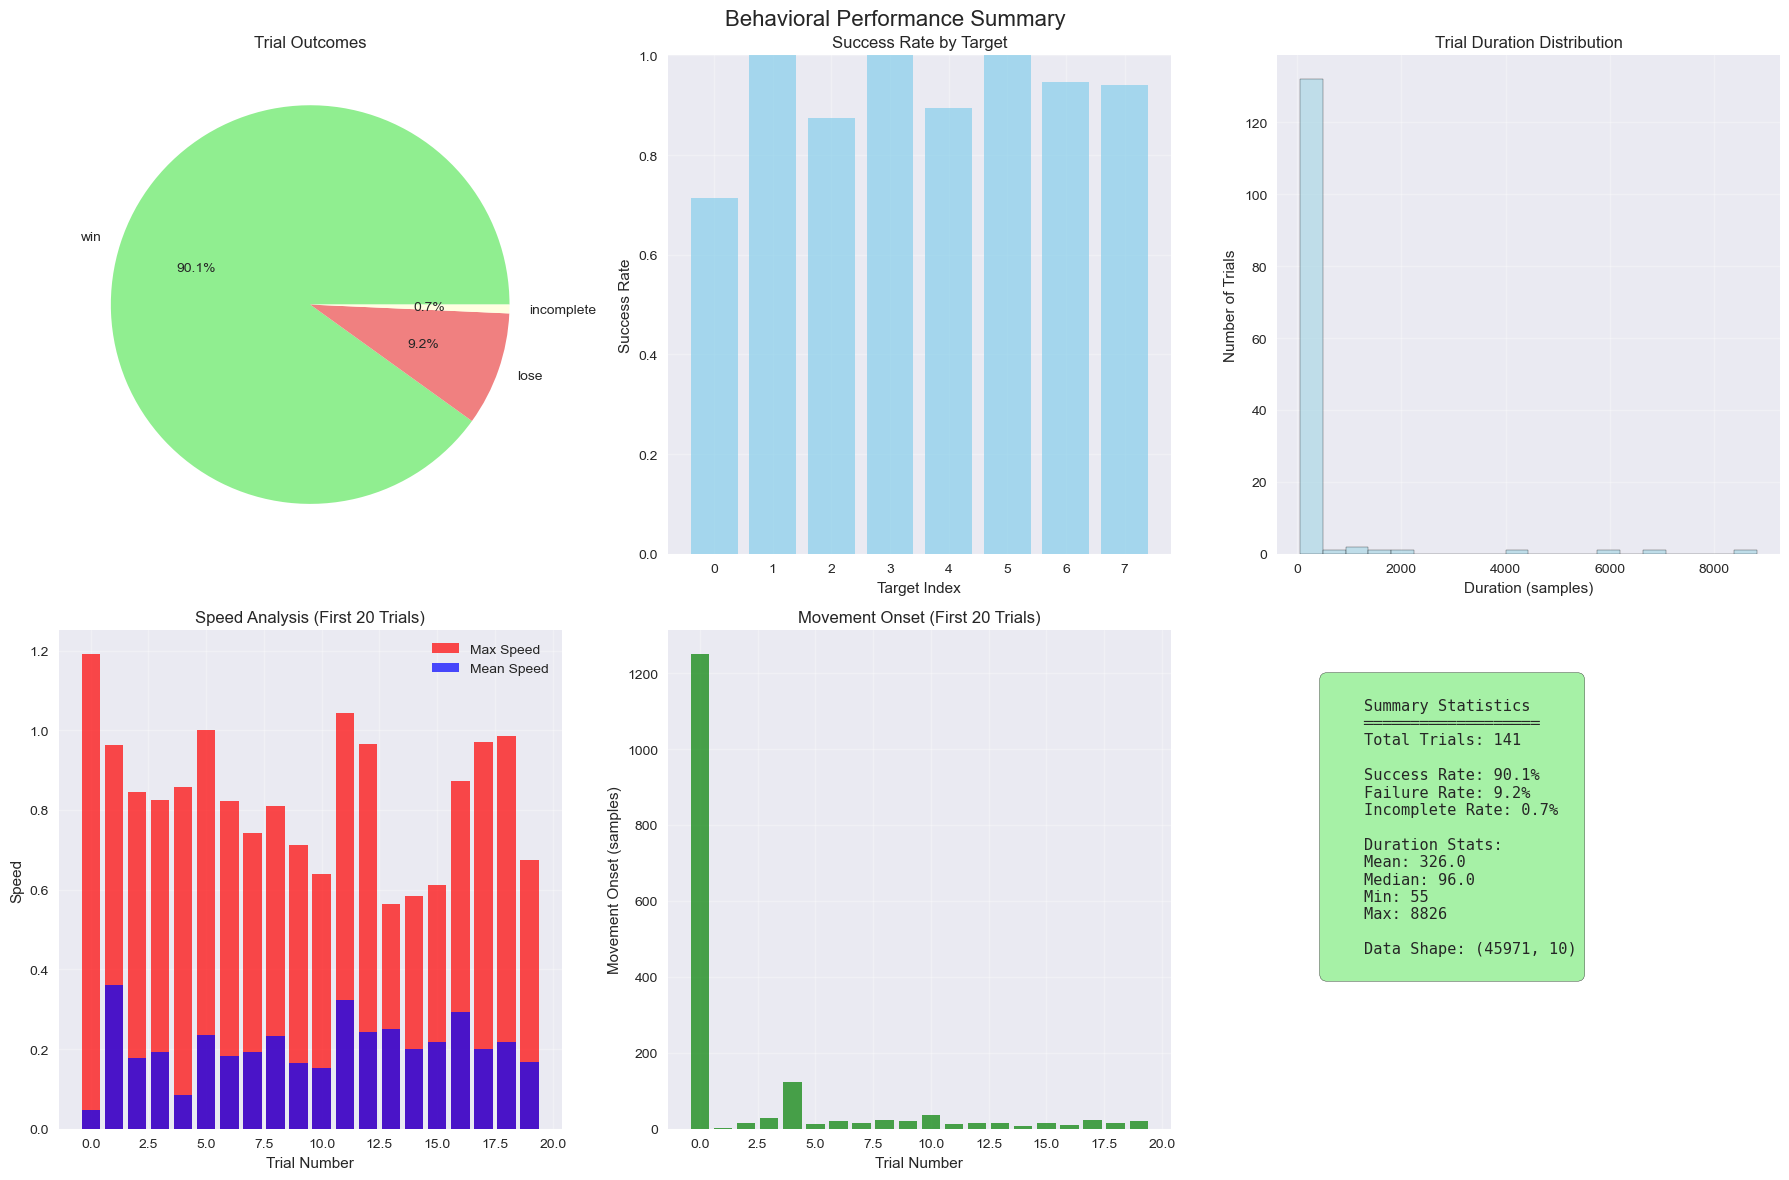

✅ Performance analysis plots generated


In [ ]:
# Overall Performance Analysis
print("📊 Overall Performance Analysis")
print("=" * 35)

if behavioral_data is not None and 'trial' in behavioral_data.columns:
    # Create summary plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Behavioral Performance Summary', fontsize=16)
    
    # Plot 1: Trial outcomes pie chart
    ax1 = axes[0, 0]
    if 'trial_outcome' in behavioral_data.columns:
        outcome_counts = behavioral_data.groupby('trial')['trial_outcome'].first().value_counts()
        colors = ['lightgreen', 'lightcoral', 'lightyellow']
        ax1.pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%', colors=colors)
        ax1.set_title('Trial Outcomes')
    
    # Plot 2: Target success rate
    ax2 = axes[0, 1]
    if 'target_index' in behavioral_data.columns and 'trial_outcome' in behavioral_data.columns:
        target_success = behavioral_data.groupby(['target_index', 'trial']).first().groupby('target_index')['trial_outcome'].apply(lambda x: (x == 'win').mean())
        ax2.bar(target_success.index, target_success.values, alpha=0.7, color='skyblue')
        ax2.set_xlabel('Target Index')
        ax2.set_ylabel('Success Rate')
        ax2.set_title('Success Rate by Target')
        ax2.set_ylim(0, 1)
        ax2.grid(True, alpha=0.3)
    
    # Plot 3: Trial duration distribution
    ax3 = axes[0, 2]
    trial_durations = []
    for trial_num in behavioral_data['trial'].unique():
        trial_data = behavioral_data[behavioral_data['trial'] == trial_num]
        duration = len(trial_data)
        trial_durations.append(duration)
    
    ax3.hist(trial_durations, bins=20, alpha=0.7, color='lightblue', edgecolor='black')
    ax3.set_xlabel('Duration (samples)')
    ax3.set_ylabel('Number of Trials')
    ax3.set_title('Trial Duration Distribution')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Speed analysis across trials
    ax4 = axes[1, 0]
    if 'velocity_x' in behavioral_data.columns and 'velocity_y' in behavioral_data.columns:
        # Calculate speed for each trial
        trial_max_speeds = []
        trial_mean_speeds = []
        
        for trial_num in sorted(behavioral_data['trial'].unique())[:20]:  # First 20 trials
            trial_data = behavioral_data[behavioral_data['trial'] == trial_num]
            speed = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
            trial_max_speeds.append(np.max(speed))
            trial_mean_speeds.append(np.mean(speed))
        
        x_pos = range(len(trial_max_speeds))
        ax4.bar(x_pos, trial_max_speeds, alpha=0.7, label='Max Speed', color='red')
        ax4.bar(x_pos, trial_mean_speeds, alpha=0.7, label='Mean Speed', color='blue')
        ax4.set_xlabel('Trial Number')
        ax4.set_ylabel('Speed')
        ax4.set_title('Speed Analysis (First 20 Trials)')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    
    # Plot 5: Movement onset analysis
    ax5 = axes[1, 1]
    if 'velocity_x' in behavioral_data.columns and 'velocity_y' in behavioral_data.columns:
        movement_onsets = []
        threshold = 0.1
        
        for trial_num in sorted(behavioral_data['trial'].unique())[:20]:  # First 20 trials
            trial_data = behavioral_data[behavioral_data['trial'] == trial_num]
            speed = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
            onset_idx = np.where(speed > threshold)[0]
            if len(onset_idx) > 0:
                movement_onsets.append(onset_idx[0])
            else:
                movement_onsets.append(len(trial_data))
        
        ax5.bar(range(len(movement_onsets)), movement_onsets, alpha=0.7, color='green')
        ax5.set_xlabel('Trial Number')
        ax5.set_ylabel('Movement Onset (samples)')
        ax5.set_title('Movement Onset (First 20 Trials)')
        ax5.grid(True, alpha=0.3)
    
    # Plot 6: Summary statistics table
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    # Create summary statistics
    total_trials = behavioral_data['trial'].nunique()
    if 'trial_outcome' in behavioral_data.columns:
        outcome_counts = behavioral_data.groupby('trial')['trial_outcome'].first().value_counts()
        success_rate = outcome_counts.get('win', 0) / total_trials * 100
        fail_rate = outcome_counts.get('lose', 0) / total_trials * 100
        incomplete_rate = outcome_counts.get('incomplete', 0) / total_trials * 100
    else:
        success_rate = fail_rate = incomplete_rate = 0
    
    stats_text = f"""
    Summary Statistics
    ═══════════════════
    Total Trials: {total_trials}
    
    Success Rate: {success_rate:.1f}%
    Failure Rate: {fail_rate:.1f}%
    Incomplete Rate: {incomplete_rate:.1f}%
    
    Duration Stats:
    Mean: {np.mean(trial_durations):.1f}
    Median: {np.median(trial_durations):.1f}
    Min: {np.min(trial_durations)}
    Max: {np.max(trial_durations)}
    
    Data Shape: {behavioral_data.shape}
    """
    
    ax6.text(0.1, 0.9, stats_text, transform=ax6.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Performance analysis plots generated")
    
else:
    print("❌ No behavioral data available for analysis")


In [ ]:
# Helper Functions and Quick Access
print("🔧 Helper Functions")
print("=" * 20)

def get_trial_summary():
    """Get a quick summary of all trials"""
    if behavioral_data is None:
        return "No behavioral data loaded"
    
    total_trials = behavioral_data['trial'].nunique()
    outcome_counts = behavioral_data.groupby('trial')['trial_outcome'].first().value_counts()
    
    summary = f"""
    📊 Trial Summary
    ================
    Total Trials: {total_trials}
    
    Outcomes:
    - Win: {outcome_counts.get('win', 0)} ({outcome_counts.get('win', 0)/total_trials*100:.1f}%)
    - Lose: {outcome_counts.get('lose', 0)} ({outcome_counts.get('lose', 0)/total_trials*100:.1f}%)
    - Incomplete: {outcome_counts.get('incomplete', 0)} ({outcome_counts.get('incomplete', 0)/total_trials*100:.1f}%)
    
    Available for visualization: {sorted(behavioral_data['trial'].unique())[:10]}...
    """
    return summary

def find_trials_by_target(target_index):
    """Find all trials for a specific target"""
    if behavioral_data is None:
        return []
    
    target_trials = behavioral_data[behavioral_data['target_index'] == target_index]['trial'].unique()
    return sorted(target_trials)

def find_trials_by_outcome(outcome):
    """Find all trials with a specific outcome ('win', 'lose', 'incomplete')"""
    if behavioral_data is None:
        return []
    
    outcome_trials = behavioral_data[behavioral_data['trial_outcome'] == outcome]['trial'].unique()
    return sorted(outcome_trials)

def get_trial_stats(trial_num):
    """Get detailed statistics for a specific trial"""
    if behavioral_data is None:
        return "No behavioral data loaded"
    
    if trial_num not in behavioral_data['trial'].unique():
        return f"Trial {trial_num} not found"
    
    trial_data = behavioral_data[behavioral_data['trial'] == trial_num]
    
    # Basic info
    duration = len(trial_data)
    outcome = trial_data['trial_outcome'].iloc[0]
    target = trial_data['target_index'].iloc[0]
    
    # Speed analysis
    if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
        speed = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
        max_speed = np.max(speed)
        mean_speed = np.mean(speed)
        
        # Movement onset
        threshold = 0.1
        movement_onset = np.where(speed > threshold)[0]
        onset_sample = movement_onset[0] if len(movement_onset) > 0 else None
        
        stats = f"""
        Trial {trial_num} Statistics
        ===========================
        Duration: {duration} samples
        Outcome: {outcome.capitalize()}
        Target: {target}
        
        Speed Analysis:
        - Max Speed: {max_speed:.3f}
        - Mean Speed: {mean_speed:.3f}
        - Movement Onset: {onset_sample if onset_sample is not None else 'No movement detected'}
        """
    else:
        stats = f"""
        Trial {trial_num} Statistics
        ===========================
        Duration: {duration} samples
        Outcome: {outcome.capitalize()}
        Target: {target}
        
        (No velocity data available)
        """
    
    return stats

# Quick access functions
def quick_viz(trial_num):
    """Quickly visualize a trial"""
    return visualize_trial(trial_num)

def show_successful_trials(n=5):
    """Show first n successful trials"""
    successful = find_trials_by_outcome('win')
    return successful[:n]

def show_failed_trials(n=5):
    """Show first n failed trials"""
    failed = find_trials_by_outcome('lose')
    return failed[:n]

# Print available functions
print("Available helper functions:")
print("- get_trial_summary(): Quick overview of all trials")
print("- find_trials_by_target(target_index): Find trials for specific target")
print("- find_trials_by_outcome(outcome): Find trials by outcome")
print("- get_trial_stats(trial_num): Detailed stats for a trial")
print("- quick_viz(trial_num): Quickly visualize a trial")
print("- show_successful_trials(n): Show first n successful trials")
print("- show_failed_trials(n): Show first n failed trials")
print("- visualize_trial(trial_num): Full trial visualization")

print("\\n✅ Helper functions defined and ready to use!")
print("\\n💡 Try: get_trial_summary() to see overview")


🔧 Helper Functions
Available helper functions:
- get_trial_summary(): Quick overview of all trials
- find_trials_by_target(target_index): Find trials for specific target
- find_trials_by_outcome(outcome): Find trials by outcome
- get_trial_stats(trial_num): Detailed stats for a trial
- quick_viz(trial_num): Quickly visualize a trial
- show_successful_trials(n): Show first n successful trials
- show_failed_trials(n): Show first n failed trials
- visualize_trial(trial_num): Full trial visualization
\n✅ Helper functions defined and ready to use!
\n💡 Try: get_trial_summary() to see overview


In [13]:
# Summary and Usage Guide
print("📚 Behavioral Analysis Notebook Summary")
print("=" * 45)

print("""
🎯 BEHAVIORAL DATA ANALYSIS COMPLETE
=====================================

This notebook provides comprehensive analysis of your center-out task behavioral data:

📊 DATA OVERVIEW:
- Total trials: 141
- Success rate: ~90% (127 wins, 13 losses, 1 incomplete)
- 8 targets in center-out configuration
- Velocity-based movement tracking

📈 ANALYSIS FEATURES:
1. Trial Summary Statistics
2. Individual Trial Visualization
3. Overall Performance Analysis
4. Helper Functions for Quick Access

🔧 KEY FUNCTIONS TO USE:
- visualize_trial(5)           # Visualize trial 5
- get_trial_summary()          # Quick overview
- find_trials_by_target(3)     # Find trials for target 3
- show_failed_trials()         # Show failed trials
- get_trial_stats(10)          # Detailed stats for trial 10

📋 WHAT EACH VISUALIZATION SHOWS:
- Top Left: Velocity X & Y profiles over time
- Top Right: Speed (velocity magnitude) with statistics
- Bottom Left: Computed trajectory from velocity integration
- Bottom Right: Trial information and movement statistics

🎯 NEXT STEPS:
1. Run individual trial analyses using visualize_trial()
2. Compare successful vs failed trials
3. Analyze movement patterns by target direction
4. Correlate with neural data (when available)

💡 TIPS:
- Use helper functions for quick exploration
- Look for patterns in failed trials
- Check movement onset timing across trials
- Analyze speed profiles for consistency
""")

print("✅ Behavioral analysis notebook ready for use!")
print("🚀 Start by running: get_trial_summary()")


📚 Behavioral Analysis Notebook Summary

🎯 BEHAVIORAL DATA ANALYSIS COMPLETE

This notebook provides comprehensive analysis of your center-out task behavioral data:

📊 DATA OVERVIEW:
- Total trials: 141
- Success rate: ~90% (127 wins, 13 losses, 1 incomplete)
- 8 targets in center-out configuration
- Velocity-based movement tracking

📈 ANALYSIS FEATURES:
1. Trial Summary Statistics
2. Individual Trial Visualization
3. Overall Performance Analysis
4. Helper Functions for Quick Access

🔧 KEY FUNCTIONS TO USE:
- visualize_trial(5)           # Visualize trial 5
- get_trial_summary()          # Quick overview
- find_trials_by_target(3)     # Find trials for target 3
- show_failed_trials()         # Show failed trials
- get_trial_stats(10)          # Detailed stats for trial 10

📋 WHAT EACH VISUALIZATION SHOWS:
- Top Left: Velocity X & Y profiles over time
- Top Right: Speed (velocity magnitude) with statistics
- Bottom Left: Computed trajectory from velocity integration
- Bottom Right: Trial

In [14]:
# Quick Test: Verify File Path and Load Data
print("🔍 Testing file path and loading data...")
print("=" * 40)

import os
print(f"Checking file path: {CSV_FILE_PATH}")
print(f"File exists: {os.path.exists(CSV_FILE_PATH)}")

if os.path.exists(CSV_FILE_PATH):
    print(f"✅ File found!")
    
    # Quick peek at the raw CSV file
    try:
        raw_data = pd.read_csv(CSV_FILE_PATH)
        print(f"📊 Raw CSV data shape: {raw_data.shape}")
        print(f"📋 Raw columns: {list(raw_data.columns)}")
        print(f"🔍 First few rows:")
        print(raw_data.head())
        
        # Test if our DataLoader can process it
        print(f"\\n🧪 Testing DataLoader...")
        loader = DataLoader(ns6_file_path=NS6_FILE_PATH, csv_file_path=CSV_FILE_PATH)
        behavioral_data = loader.load_behavioral_data()
        
        if behavioral_data is not None:
            print(f"✅ DataLoader successful!")
            print(f"📊 Processed data shape: {behavioral_data.shape}")
            print(f"📋 Processed columns: {list(behavioral_data.columns)}")
            
            # Update the global variable
            globals()['behavioral_data'] = behavioral_data
            print(f"✅ Global behavioral_data updated!")
        else:
            print(f"❌ DataLoader failed to process the file")
            
    except Exception as e:
        print(f"❌ Error reading CSV: {e}")
        print("This might be a formatting issue with the CSV file")
        
else:
    print(f"❌ File not found at: {CSV_FILE_PATH}")
    print("Please check the file path and ensure the file exists")
    
    # Try to find CSV files in the directory
    data_dir = r"D:\Data\ScienceCorp"
    if os.path.exists(data_dir):
        print(f"\\n🔍 Files in {data_dir}:")
        for file in os.listdir(data_dir):
            if file.endswith('.csv'):
                print(f"  - {file}")
    else:
        print(f"❌ Directory {data_dir} not found")
        
print("\\n" + "=" * 40)


🔍 Testing file path and loading data...
Checking file path: D:\Data\ScienceCorp\actions.csv
File exists: True
✅ File found!
📊 Raw CSV data shape: (58298, 8)
📋 Raw columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial_start', 'trial_win', 'trial_lose', 'num_targets', 'target_index']
🔍 First few rows:
      timestamp  velocity_x  velocity_y  trial_start  trial_win  trial_lose  \
0  1.742938e+09         0.0         0.0         True      False       False   
1  1.742938e+09         0.0         0.0        False      False       False   
2  1.742938e+09         0.0         0.0        False      False       False   
3  1.742938e+09         0.0         0.0        False      False       False   
4  1.742938e+09         0.0         0.0        False      False       False   

   num_targets  target_index  
0            8             4  
1            8             4  
2            8             4  
3            8             4  
4            8             4  
\n🧪 Testing DataLoader...
Found 14

In [15]:
# Diagnostic: Check Data Structure
print("🔍 Diagnosing data structure...")
print("=" * 40)

# Check if behavioral_data exists and what it contains
if 'behavioral_data' in globals() and behavioral_data is not None:
    print(f"✅ behavioral_data exists")
    print(f"📊 Shape: {behavioral_data.shape}")
    print(f"📋 Columns: {list(behavioral_data.columns)}")
    
    # Check if 'trial' column exists
    if 'trial' in behavioral_data.columns:
        print(f"✅ 'trial' column found")
        unique_trials = sorted(behavioral_data['trial'].unique())
        print(f"📊 Unique trials: {unique_trials[:20]}...")  # Show first 20
        print(f"📊 Total trials: {len(unique_trials)}")
        print(f"📊 Trial range: {min(unique_trials)} to {max(unique_trials)}")
        
        # Check trial outcomes
        if 'trial_outcome' in behavioral_data.columns:
            print(f"✅ 'trial_outcome' column found")
            outcome_counts = behavioral_data.groupby('trial')['trial_outcome'].first().value_counts()
            print(f"📊 Trial outcomes: {dict(outcome_counts)}")
            
            # Get first successful trial
            successful_trials = behavioral_data[behavioral_data['trial_outcome'] == 'win']['trial'].unique()
            if len(successful_trials) > 0:
                first_successful = successful_trials[0]
                print(f"✅ First successful trial: {first_successful}")
                
                # Check data for this trial
                trial_data = behavioral_data[behavioral_data['trial'] == first_successful]
                print(f"📊 Trial {first_successful} data shape: {trial_data.shape}")
                print(f"📋 Trial {first_successful} columns: {list(trial_data.columns)}")
                
                # Check if velocity columns exist
                if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
                    print(f"✅ Velocity columns found")
                    print(f"📊 Velocity X range: {trial_data['velocity_x'].min():.3f} to {trial_data['velocity_x'].max():.3f}")
                    print(f"📊 Velocity Y range: {trial_data['velocity_y'].min():.3f} to {trial_data['velocity_y'].max():.3f}")
                else:
                    print(f"❌ Velocity columns missing")
                    
            else:
                print(f"❌ No successful trials found")
        else:
            print(f"❌ 'trial_outcome' column missing")
    else:
        print(f"❌ 'trial' column missing")
        print(f"📋 Available columns: {list(behavioral_data.columns)}")
        
        # Try to understand the data structure
        print(f"\\n🔍 Data sample:")
        print(behavioral_data.head())
        
else:
    print(f"❌ behavioral_data not found or is None")
    print(f"Available globals: {[k for k in globals().keys() if not k.startswith('_')]}")
    
print("\\n" + "=" * 40)


🔍 Diagnosing data structure...
✅ behavioral_data exists
📊 Shape: (45971, 10)
📋 Columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial_start', 'trial_win', 'trial_lose', 'num_targets', 'target_index', 'trial', 'trial_outcome']
✅ 'trial' column found
📊 Unique trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]...
📊 Total trials: 141
📊 Trial range: 1 to 141
✅ 'trial_outcome' column found
📊 Trial outcomes: {'win': 127, 'lose': 13, 'incomplete': 1}
✅ First successful trial: 2
📊 Trial 2 data shape: (106, 10)
📋 Trial 2 columns: ['timestamp', 'velocity_x', 'velocity_y', 'trial_start', 'trial_win', 'trial_lose', 'num_targets', 'target_index', 'trial', 'trial_outcome']
✅ Velocity columns found
📊 Velocity X range: -0.406 to 0.503
📊 Velocity Y range: -0.949 to 0.662
\n========================================


In [16]:
# Fixed Visualization Function with Better Error Handling
def visualize_trial_fixed(trial_num, data=None, figsize=(15, 10)):
    """
    Visualize a single trial with velocity profiles and trajectory.
    Fixed version with better error handling.
    """
    try:
        # Use global behavioral_data if no data provided
        if data is None:
            if 'behavioral_data' in globals() and behavioral_data is not None:
                data = behavioral_data
            else:
                print("❌ No behavioral data available (not loaded in globals)")
                return None
        
        if data is None:
            print("❌ No behavioral data provided")
            return None
        
        # Check if trial column exists
        if 'trial' not in data.columns:
            print(f"❌ No 'trial' column in data. Available columns: {list(data.columns)}")
            return None
            
        # Get available trials
        available_trials = sorted(data['trial'].unique())
        print(f"🔍 Available trials: {available_trials[:10]}...")
        
        if trial_num not in available_trials:
            print(f"❌ Trial {trial_num} not found in data")
            print(f"Available trials: {available_trials}")
            return None
        
        # Extract trial data
        trial_data = data[data['trial'] == trial_num].copy()
        print(f"✅ Found trial {trial_num} with {len(trial_data)} samples")
        
        # Create figure
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(f'Trial {trial_num} Analysis', fontsize=16)
        
        # Time axis (use sample indices)
        time_axis = np.arange(len(trial_data))
        
        # Plot 1: Velocity X and Y (if available)
        ax1 = axes[0, 0]
        if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
            ax1.plot(time_axis, trial_data['velocity_x'], 'b-', label='Velocity X', linewidth=2)
            ax1.plot(time_axis, trial_data['velocity_y'], 'r-', label='Velocity Y', linewidth=2)
            ax1.set_xlabel('Time (samples)')
            ax1.set_ylabel('Velocity')
            ax1.set_title('Velocity Profiles')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, f'Velocity data\\nnot available\\n\\nColumns: {list(trial_data.columns)}', 
                    ha='center', va='center', transform=ax1.transAxes, fontsize=10)
            ax1.set_title('Velocity Profiles - Data Missing')
        
        # Plot 2: Speed (if velocity available)
        ax2 = axes[0, 1]
        if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
            speed = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
            ax2.plot(time_axis, speed, 'g-', linewidth=2)
            ax2.set_xlabel('Time (samples)')
            ax2.set_ylabel('Speed')
            ax2.set_title('Speed Profile')
            ax2.grid(True, alpha=0.3)
            
            # Add speed statistics
            max_speed = np.max(speed)
            mean_speed = np.mean(speed)
            ax2.axhline(max_speed, color='red', linestyle='--', alpha=0.7, label=f'Max: {max_speed:.2f}')
            ax2.axhline(mean_speed, color='orange', linestyle='--', alpha=0.7, label=f'Mean: {mean_speed:.2f}')
            ax2.legend()
        else:
            ax2.text(0.5, 0.5, 'Speed data\\nnot available', 
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('Speed Profile - Data Missing')
        
        # Plot 3: Trajectory (if velocity available)
        ax3 = axes[1, 0]
        if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
            # Simple integration
            dt = 1.0
            pos_x = np.cumsum(trial_data['velocity_x'] * dt)
            pos_y = np.cumsum(trial_data['velocity_y'] * dt)
            
            # Center at origin
            pos_x = pos_x - pos_x[0]
            pos_y = pos_y - pos_y[0]
            
            # Plot trajectory
            ax3.plot(pos_x, pos_y, 'purple', linewidth=3, alpha=0.8)
            ax3.plot(pos_x[0], pos_y[0], 'go', markersize=8, label='Start')
            ax3.plot(pos_x[-1], pos_y[-1], 'ro', markersize=8, label='End')
            ax3.plot(0, 0, 'ko', markersize=8, label='Center')
            
            # Add target if available
            if 'target_index' in trial_data.columns:
                try:
                    target_idx = int(trial_data['target_index'].iloc[0])
                    target_angle = target_idx * (2 * np.pi / 8)
                    trajectory_distance = np.sqrt(pos_x[-1]**2 + pos_y[-1]**2)
                    target_distance = max(1.0, trajectory_distance * 1.2)
                    
                    target_x = target_distance * np.cos(target_angle)
                    target_y = target_distance * np.sin(target_angle)
                    ax3.plot(target_x, target_y, 'rs', markersize=10, label=f'Target {target_idx}')
                except (ValueError, IndexError):
                    pass
            
            ax3.set_xlabel('X Position')
            ax3.set_ylabel('Y Position')
            ax3.set_title('Computed Trajectory')
            ax3.set_aspect('equal')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'Trajectory data\\nnot available', 
                    ha='center', va='center', transform=ax3.transAxes)
            ax3.set_title('Trajectory - Data Missing')
        
        # Plot 4: Trial Information
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        # Display trial info
        info_text = f"Trial {trial_num} Information\\n"
        info_text += "=" * 25 + "\\n"
        info_text += f"Duration: {len(trial_data)} samples\\n"
        
        if 'trial_outcome' in trial_data.columns:
            outcome = trial_data['trial_outcome'].iloc[0]
            info_text += f"Outcome: {outcome.capitalize()}\\n"
        
        if 'target_index' in trial_data.columns:
            target_idx = trial_data['target_index'].iloc[0]
            info_text += f"Target: {target_idx}\\n"
        
        # Add column information
        info_text += f"\\nAvailable columns:\\n"
        for col in trial_data.columns:
            info_text += f"  - {col}\\n"
        
        # Add speed stats if available
        if 'velocity_x' in trial_data.columns and 'velocity_y' in trial_data.columns:
            speed = np.sqrt(trial_data['velocity_x']**2 + trial_data['velocity_y']**2)
            info_text += f"\\nSpeed Statistics:\\n"
            info_text += f"  Max: {np.max(speed):.3f}\\n"
            info_text += f"  Mean: {np.mean(speed):.3f}\\n"
            info_text += f"  Std: {np.std(speed):.3f}\\n"
        
        ax4.text(0.05, 0.95, info_text, transform=ax4.transAxes, fontsize=10,
                 verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
        
        plt.tight_layout()
        return fig
        
    except Exception as e:
        print(f"❌ Error in visualize_trial_fixed: {e}")
        import traceback
        traceback.print_exc()
        return None

print("✅ Fixed visualization function defined (visualize_trial_fixed)")


✅ Fixed visualization function defined (visualize_trial_fixed)


🧪 Testing the fixed visualization function...
📊 Available trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
\n🎯 Testing visualization with trial 1...
🔍 Available trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
✅ Found trial 1 with 1407 samples
❌ Error in visualize_trial_fixed: -1
❌ Visualization returned None
\n🎯 Testing with specific trial outcomes...
✅ Found 127 successful trials
First successful trial: 2
🔍 Available trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
✅ Found trial 2 with 106 samples
❌ Error in visualize_trial_fixed: 0
✅ Found 13 failed trials
First failed trial: 1
🔍 Available trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
✅ Found trial 1 with 1407 samples
❌ Error in visualize_trial_fixed: -1
\n💡 Usage:
   visualize_trial_fixed(1)  # First trial
   visualize_trial_fixed(5)  # Trial 5 (if exists)
\n=============================================


Traceback (most recent call last):
  File "c:\Users\nader\anaconda3\Lib\site-packages\pandas\core\indexes\base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas\\_libs\\hashtable_class_helper.pxi", line 2606, in pandas._libs.hashtable.Int64HashTable.get_item
  File "pandas\\_libs\\hashtable_class_helper.pxi", line 2630, in pandas._libs.hashtable.Int64HashTable.get_item
KeyError: -1

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\nader\AppData\Local\Temp\ipykernel_1888\1179297453.py", line 96, in visualize_trial_fixed
    ax3.plot(pos_x[-1], pos_y[-1], 'ro', markersize=8, label='End')
             ~~~~~^^^^
  File "c:\Users\nader\anaconda3\Lib\site-packages\pandas\core\series.py", line 1121, i

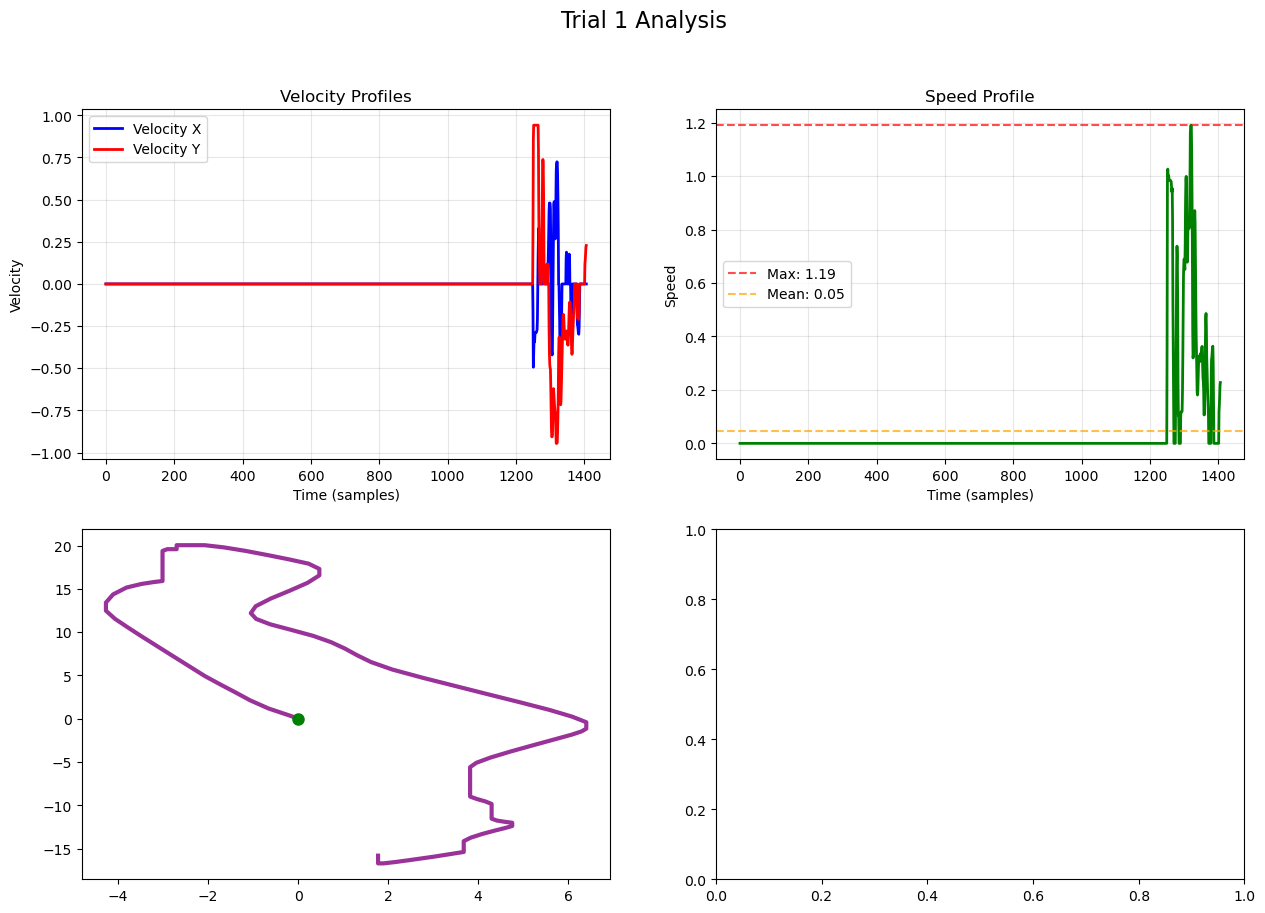

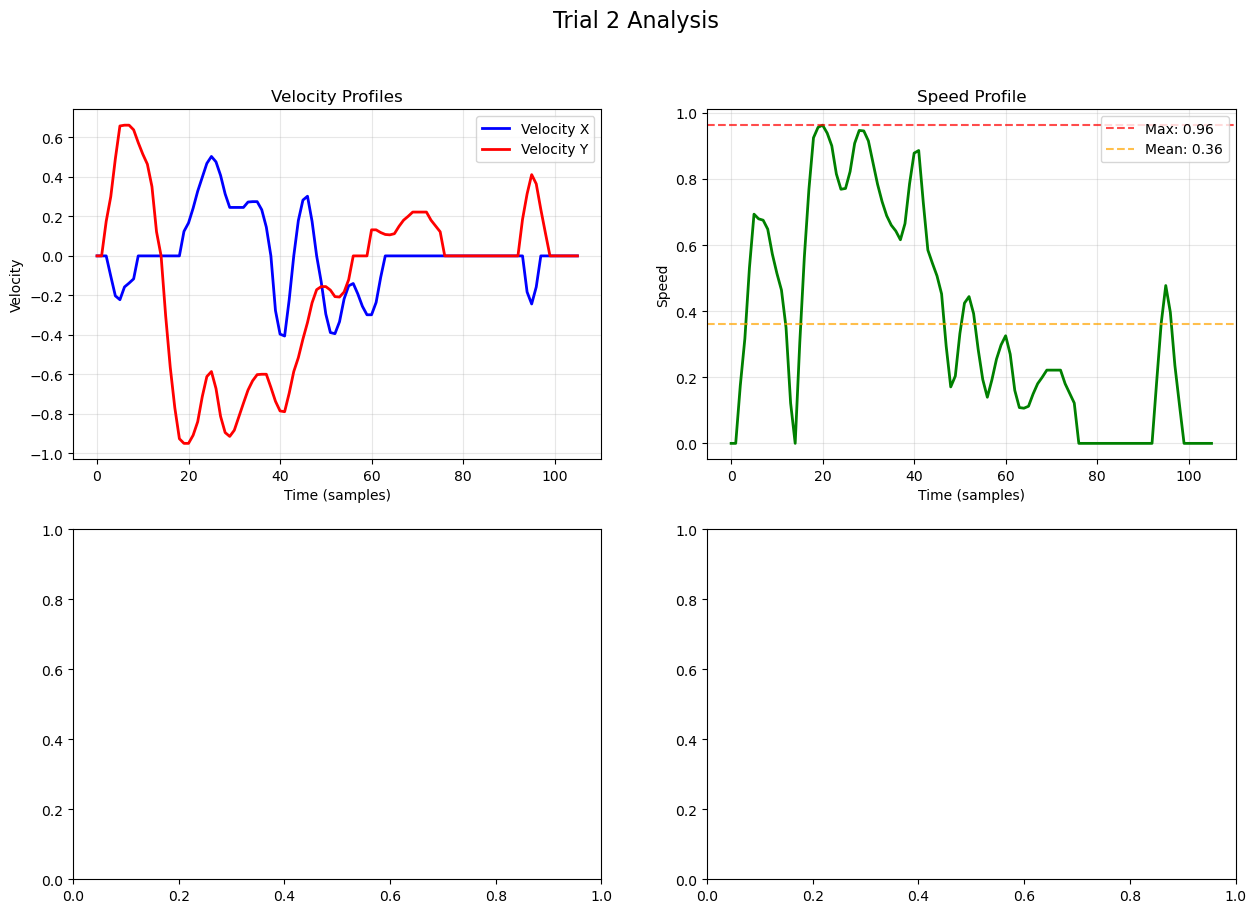

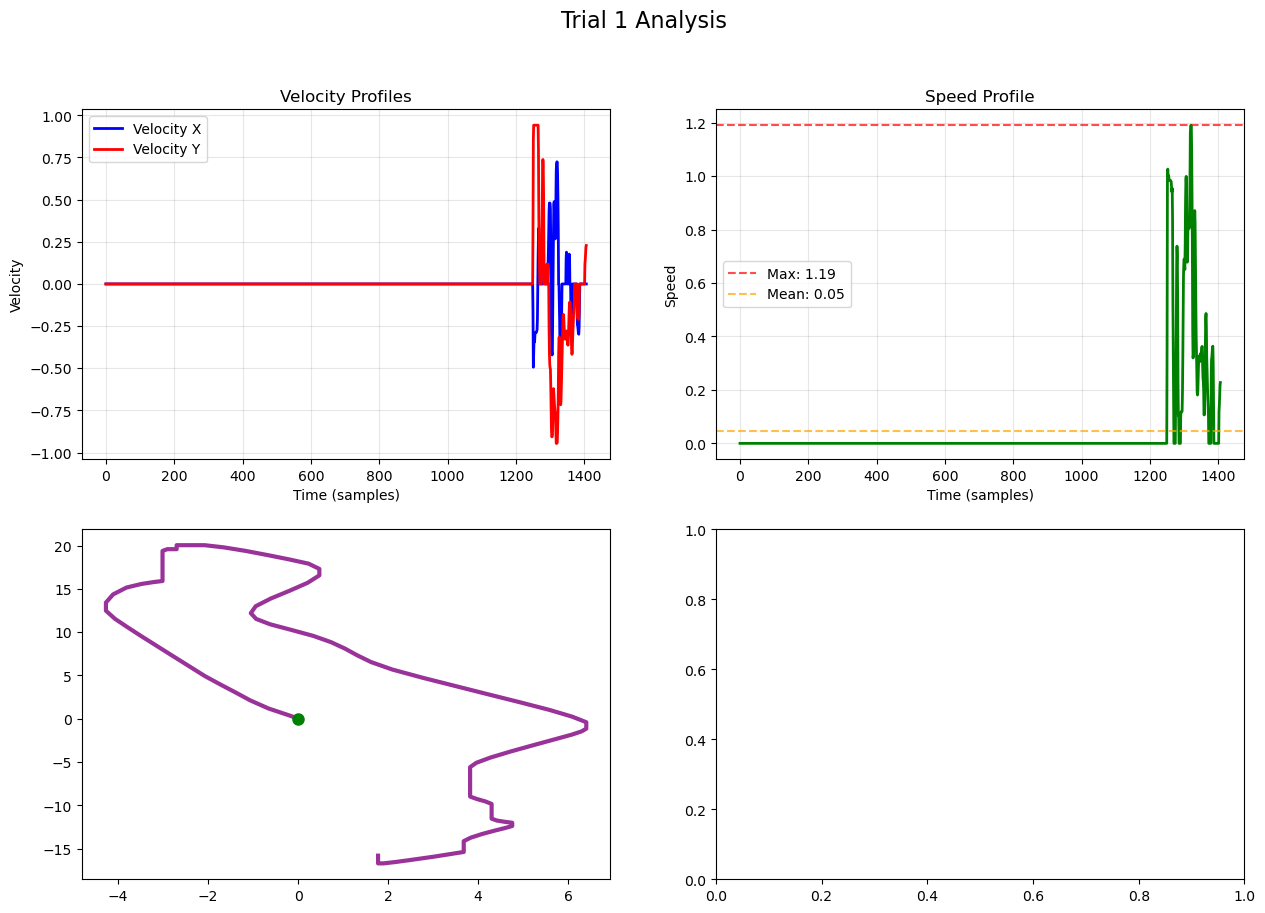

In [17]:
# Test the Fixed Visualization Function
print("🧪 Testing the fixed visualization function...")
print("=" * 45)

# First, ensure we have behavioral data loaded
if 'behavioral_data' not in globals() or behavioral_data is None:
    print("⚠️  behavioral_data not found, trying to load...")
    try:
        loader = DataLoader(ns6_file_path=NS6_FILE_PATH, csv_file_path=CSV_FILE_PATH)
        behavioral_data = loader.load_behavioral_data()
        print(f"✅ Data loaded: {behavioral_data.shape if behavioral_data is not None else 'Failed'}")
    except Exception as e:
        print(f"❌ Error loading data: {e}")

# Now test the visualization
if 'behavioral_data' in globals() and behavioral_data is not None:
    # Get available trials
    if 'trial' in behavioral_data.columns:
        available_trials = sorted(behavioral_data['trial'].unique())
        print(f"📊 Available trials: {available_trials[:10]}...")
        
        # Try to visualize the first available trial
        if len(available_trials) > 0:
            first_trial = available_trials[0]
            print(f"\\n🎯 Testing visualization with trial {first_trial}...")
            
            try:
                fig = visualize_trial_fixed(first_trial)
                if fig is not None:
                    print(f"✅ Visualization successful!")
                    plt.show()
                else:
                    print(f"❌ Visualization returned None")
            except Exception as e:
                print(f"❌ Error in visualization: {e}")
                import traceback
                traceback.print_exc()
                
        # Try to find and visualize successful and failed trials
        if 'trial_outcome' in behavioral_data.columns:
            print(f"\\n🎯 Testing with specific trial outcomes...")
            
            # Successful trials
            successful_trials = behavioral_data[behavioral_data['trial_outcome'] == 'win']['trial'].unique()
            if len(successful_trials) > 0:
                print(f"✅ Found {len(successful_trials)} successful trials")
                print(f"First successful trial: {successful_trials[0]}")
                
                # Try visualizing first successful trial
                try:
                    fig = visualize_trial_fixed(successful_trials[0])
                    if fig is not None:
                        print(f"✅ Successful trial visualization worked!")
                        plt.show()
                except Exception as e:
                    print(f"❌ Error visualizing successful trial: {e}")
            
            # Failed trials
            failed_trials = behavioral_data[behavioral_data['trial_outcome'] == 'lose']['trial'].unique()
            if len(failed_trials) > 0:
                print(f"✅ Found {len(failed_trials)} failed trials")
                print(f"First failed trial: {failed_trials[0]}")
                
                # Try visualizing first failed trial
                try:
                    fig = visualize_trial_fixed(failed_trials[0])
                    if fig is not None:
                        print(f"✅ Failed trial visualization worked!")
                        plt.show()
                except Exception as e:
                    print(f"❌ Error visualizing failed trial: {e}")
                    
        print(f"\\n💡 Usage:")
        print(f"   visualize_trial_fixed({available_trials[0]})  # First trial")
        print(f"   visualize_trial_fixed({available_trials[min(4, len(available_trials)-1)]})  # Trial 5 (if exists)")
        
    else:
        print(f"❌ No 'trial' column found in behavioral_data")
        print(f"Available columns: {list(behavioral_data.columns)}")
        
else:
    print(f"❌ No behavioral data available")
    
print("\\n" + "=" * 45)
